In [1]:
from solver_selection_thm.thm_physics import ModelTHM, initialize, run, params
from solver_selection_thm.selector import SolverSelector
from solver_selection_thm.solver_space import CategoricalChoices, NumericalChoices
from solver_selection_thm.performance_predictor import (
    PerformancePredictorPassiveAgressive,
    PerformancePredictorEpsGreedy,
    RewardEstimator,
)
from solver_selection_thm.solver_space import SolverSpace
from solver_selection_thm.pp_binding import (
    KNOWN_SOLVER_COMPONENTS_THM,
    SolverSelectionMixinTHM,
)
from thm_runscript import make_solver_space_scheme_fthm
import numpy as np
from matplotlib import pyplot as plt

/home/porepy/porepy/src/porepy/utils/ui_and_logging.py:45: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import trange as progressbar_class  # type: ignore


In [2]:
import pickle
from itertools import count
from copy import copy
from plot_utils import (
    color_converged_reason,
    color_time_steps,
    get_gmres_iterations,
    load_data,
    get_cfl,
    get_enthalpy_max,
    get_peclet_max,
    get_temp_max,
    get_temp_min,
    get_num_sticking_sliding_open,
)
from solver_selection_thm.thm_runscript import inlet_placements, outlet_placements
from solver_selection_thm.thm_physics import simulation_name


# RUNS = [0,1,2,8,9]
RUNS = [20,21,22,23,24]

data_simulations_common = []
solver_selection_history_common = []

for run_idx in RUNS:

    with open(f"../stats/thm_solver_space_scheme_run_{run_idx}.pkl", "rb") as f:
        solver_space_scheme = pickle.load(f)

    # Load permutations
    with open(f"../stats/thm_permutations_{run_idx}.pkl", "rb") as f:
        permutations = pickle.load(f)
        permutations_inlet = permutations['inlet']
        permutations_outlet = permutations['outlet']

    solver_space = SolverSpace(
        solver_space_scheme=solver_space_scheme,
        solver_scheme_builders=KNOWN_SOLVER_COMPONENTS_THM,
    )
    num_solvers = len(solver_space.all_decisions_encoding)
    print("Num solvers:", num_solvers)

    performance_predictor = PerformancePredictorPassiveAgressive(
        num_solvers=num_solvers,
    )
    solver_selector = SolverSelector(
        solver_space=solver_space,
        performance_predictor=performance_predictor,
    )

    
    data_simulations = []
    solver_selection_history = []
    data_simulations_common.append(data_simulations)
    solver_selection_history_common.append(solver_selection_history)

    inlet_placements = np.array(inlet_placements)
    outlet_placements = np.array(outlet_placements)

    for inlet_placement in inlet_placements[permutations_inlet]:
        data_row = []
        data_simulations.append(data_row)
        for outlet_placement in outlet_placements[permutations_outlet]:
            params["inlet_placement"] = inlet_placement
            params["outlet_placement"] = outlet_placement
            sim_name = f"run_{run_idx}_{simulation_name(params)}"
            try:
                data = load_data(f"../stats/{sim_name}.json")
                data_row.append(data)
                solver_selector.history.load(f"../stats/solver_selection_history_{sim_name}.npy")
                solver_selection_history.append(copy(solver_selector.history))
            except FileNotFoundError:
                print('failed to load', sim_name)

Num solvers: 448
Num solvers: 448
Num solvers: 448
Num solvers: 448
Num solvers: 448
failed to load run_24_fthm_xinj=0.0_yinj=0.5_zinj=0.5_xprod=1.0_yprod=0.5_zprod=0.5
failed to load run_24_fthm_xinj=0.0_yinj=0.5_zinj=0.5_xprod=0.7_yprod=0.0_zprod=0.5
failed to load run_24_fthm_xinj=0.0_yinj=0.5_zinj=0.5_xprod=0.52_yprod=0.5_zprod=0.5
failed to load run_24_fthm_xinj=0.0_yinj=0.5_zinj=0.5_xprod=0.7_yprod=1.0_zprod=0.5
failed to load run_24_fthm_xinj=0.48_yinj=0.5_zinj=0.5_xprod=0.7_yprod=0.5_zprod=0.5
failed to load run_24_fthm_xinj=0.48_yinj=0.5_zinj=0.5_xprod=1.0_yprod=0.5_zprod=0.5
failed to load run_24_fthm_xinj=0.48_yinj=0.5_zinj=0.5_xprod=0.7_yprod=0.0_zprod=0.5
failed to load run_24_fthm_xinj=0.48_yinj=0.5_zinj=0.5_xprod=0.52_yprod=0.5_zprod=0.5
failed to load run_24_fthm_xinj=0.48_yinj=0.5_zinj=0.5_xprod=0.7_yprod=1.0_zprod=0.5


In [21]:
from collections import defaultdict

stats_data_dict = defaultdict(lambda: [])
rewards_data_dict = defaultdict(lambda: [])


for seq_id, data_simulations, solver_selection_history_seq in zip(
    RUNS, data_simulations_common, solver_selection_history_common
):
    solver_selection_history_seq = iter(solver_selection_history_seq)
    sim_idx = -1
    for data_row in data_simulations:
        for data in data_row:
            solver_selection_history = next(solver_selection_history_seq)
            sim_idx += 1

            for reward_idx, reward in enumerate(solver_selection_history.reward):
                rewards_data_dict["seq_id"].append(seq_id)
                rewards_data_dict["sim_idx"].append(sim_idx)
                rewards_data_dict['reward'].append(reward)

            for ts_idx, ts in enumerate(data):
                for ls_idx, ls in enumerate(ts.linear_solves):
                    stats_data_dict["seq_id"].append(seq_id)
                    stats_data_dict["sim_idx"].append(sim_idx)
                    stats_data_dict["ts_idx"].append(ts_idx)
                    stats_data_dict["ls_idx"].append(ls_idx)
                    stats_data_dict["real_solve_time"].append(ls.linear_solve_time)
                    stats_data_dict['krylov_iters'].append(ls.krylov_iters)
                    stats_data_dict['petsc_converged_reason'].append(ls.petsc_converged_reason)
                    stats_data_dict['cfl'].append(ls.cfl)

                    

StopIteration: 

Text(0.5, 0, '# Linear solve')

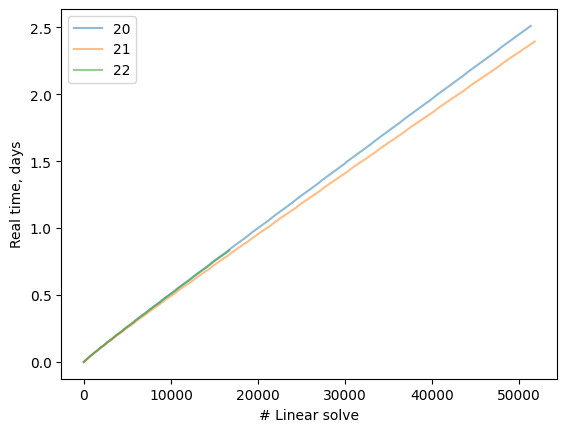

In [22]:
import pandas as pd
df_rewards = pd.DataFrame(data=rewards_data_dict)
df_rewards

FAIL_REWARD = -100
HOUR = 60 * 60
DAY = 24 * HOUR

for seq_id in RUNS:
    rewards_seq = df_rewards.reward[df_rewards.seq_id == seq_id]
    rewards_seq = np.array(rewards_seq[rewards_seq > FAIL_REWARD])
    rewards_seq = np.exp(-rewards_seq)
    plt.plot(np.cumsum(rewards_seq) / DAY, label=seq_id, alpha=0.5)
plt.legend()
plt.ylabel('Real time, days')
plt.xlabel('# Linear solve')

In [23]:
import pandas as pd

df = pd.DataFrame(data=stats_data_dict)
df

,seq_id,sim_idx,ts_idx,ls_idx,real_solve_time,krylov_iters,petsc_converged_reason,cfl
0,20,0,0,0,5.660293,44,2,2.759354e-16
1,20,0,0,1,4.974073,64,2,5.925187e-03
2,20,0,0,2,4.781746,68,2,5.928433e-03
3,20,0,0,3,4.537036,38,2,5.928433e-03
4,20,0,1,0,5.663898,93,2,5.928433e-03
...,...,...,...,...,...,...,...,...
10151,22,13,52,1,4.519110,63,2,1.096776e+01
10152,22,13,52,2,4.335775,59,2,1.096776e+01
10153,22,13,53,0,4.763699,69,2,6.157160e+00
10154,22,13,53,1,4.639739,70,2,6.157156e+00


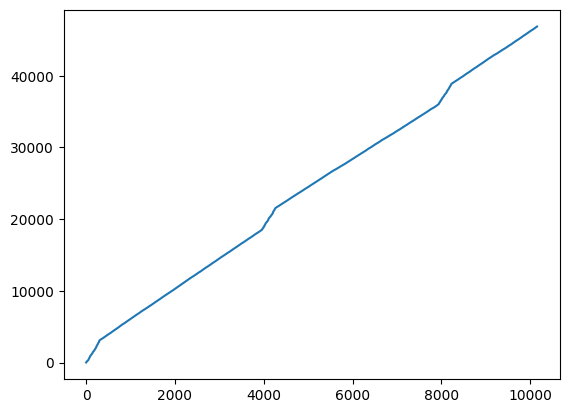

In [24]:
plt.plot(np.cumsum(df.real_solve_time))